In [2]:
# QUESTION 13 CHAP 4
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score


In [5]:
import pandas as pd

url = "https://raw.githubusercontent.com/intro-stat-learning/ISLP/main/ISLP/data/Weekly.csv"
weekly = pd.read_csv(url)
weekly.head()



,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up


In [7]:
#(a) Numerical and graphical summaries
weekly.describe()
weekly['Direction'].value_counts()


Direction
Up      605
Down    484
Name: count, dtype: int64

In [8]:
#Correlation matrix
weekly_corr = weekly.drop(columns=['Direction']).corr()
weekly_corr


,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
Year,1.000000,-0.032289,-0.033390,-0.030006,-0.031128,-0.030519,0.841942,-0.032460
Lag1,-0.032289,1.000000,-0.074853,0.058636,-0.071274,-0.008183,-0.064951,-0.075032
Lag2,-0.033390,-0.074853,1.000000,-0.075721,0.058382,-0.072499,-0.085513,0.059167
Lag3,-0.030006,0.058636,-0.075721,1.000000,-0.075396,0.060657,-0.069288,-0.071244
Lag4,-0.031128,-0.071274,0.058382,-0.075396,1.000000,-0.075675,-0.061075,-0.007826
Lag5,-0.030519,-0.008183,-0.072499,0.060657,-0.075675,1.000000,-0.058517,0.011013
Volume,0.841942,-0.064951,-0.085513,-0.069288,-0.061075,-0.058517,1.000000,-0.033078
Today,-0.032460,-0.075032,0.059167,-0.071244,-0.007826,0.011013,-0.033078,1.000000


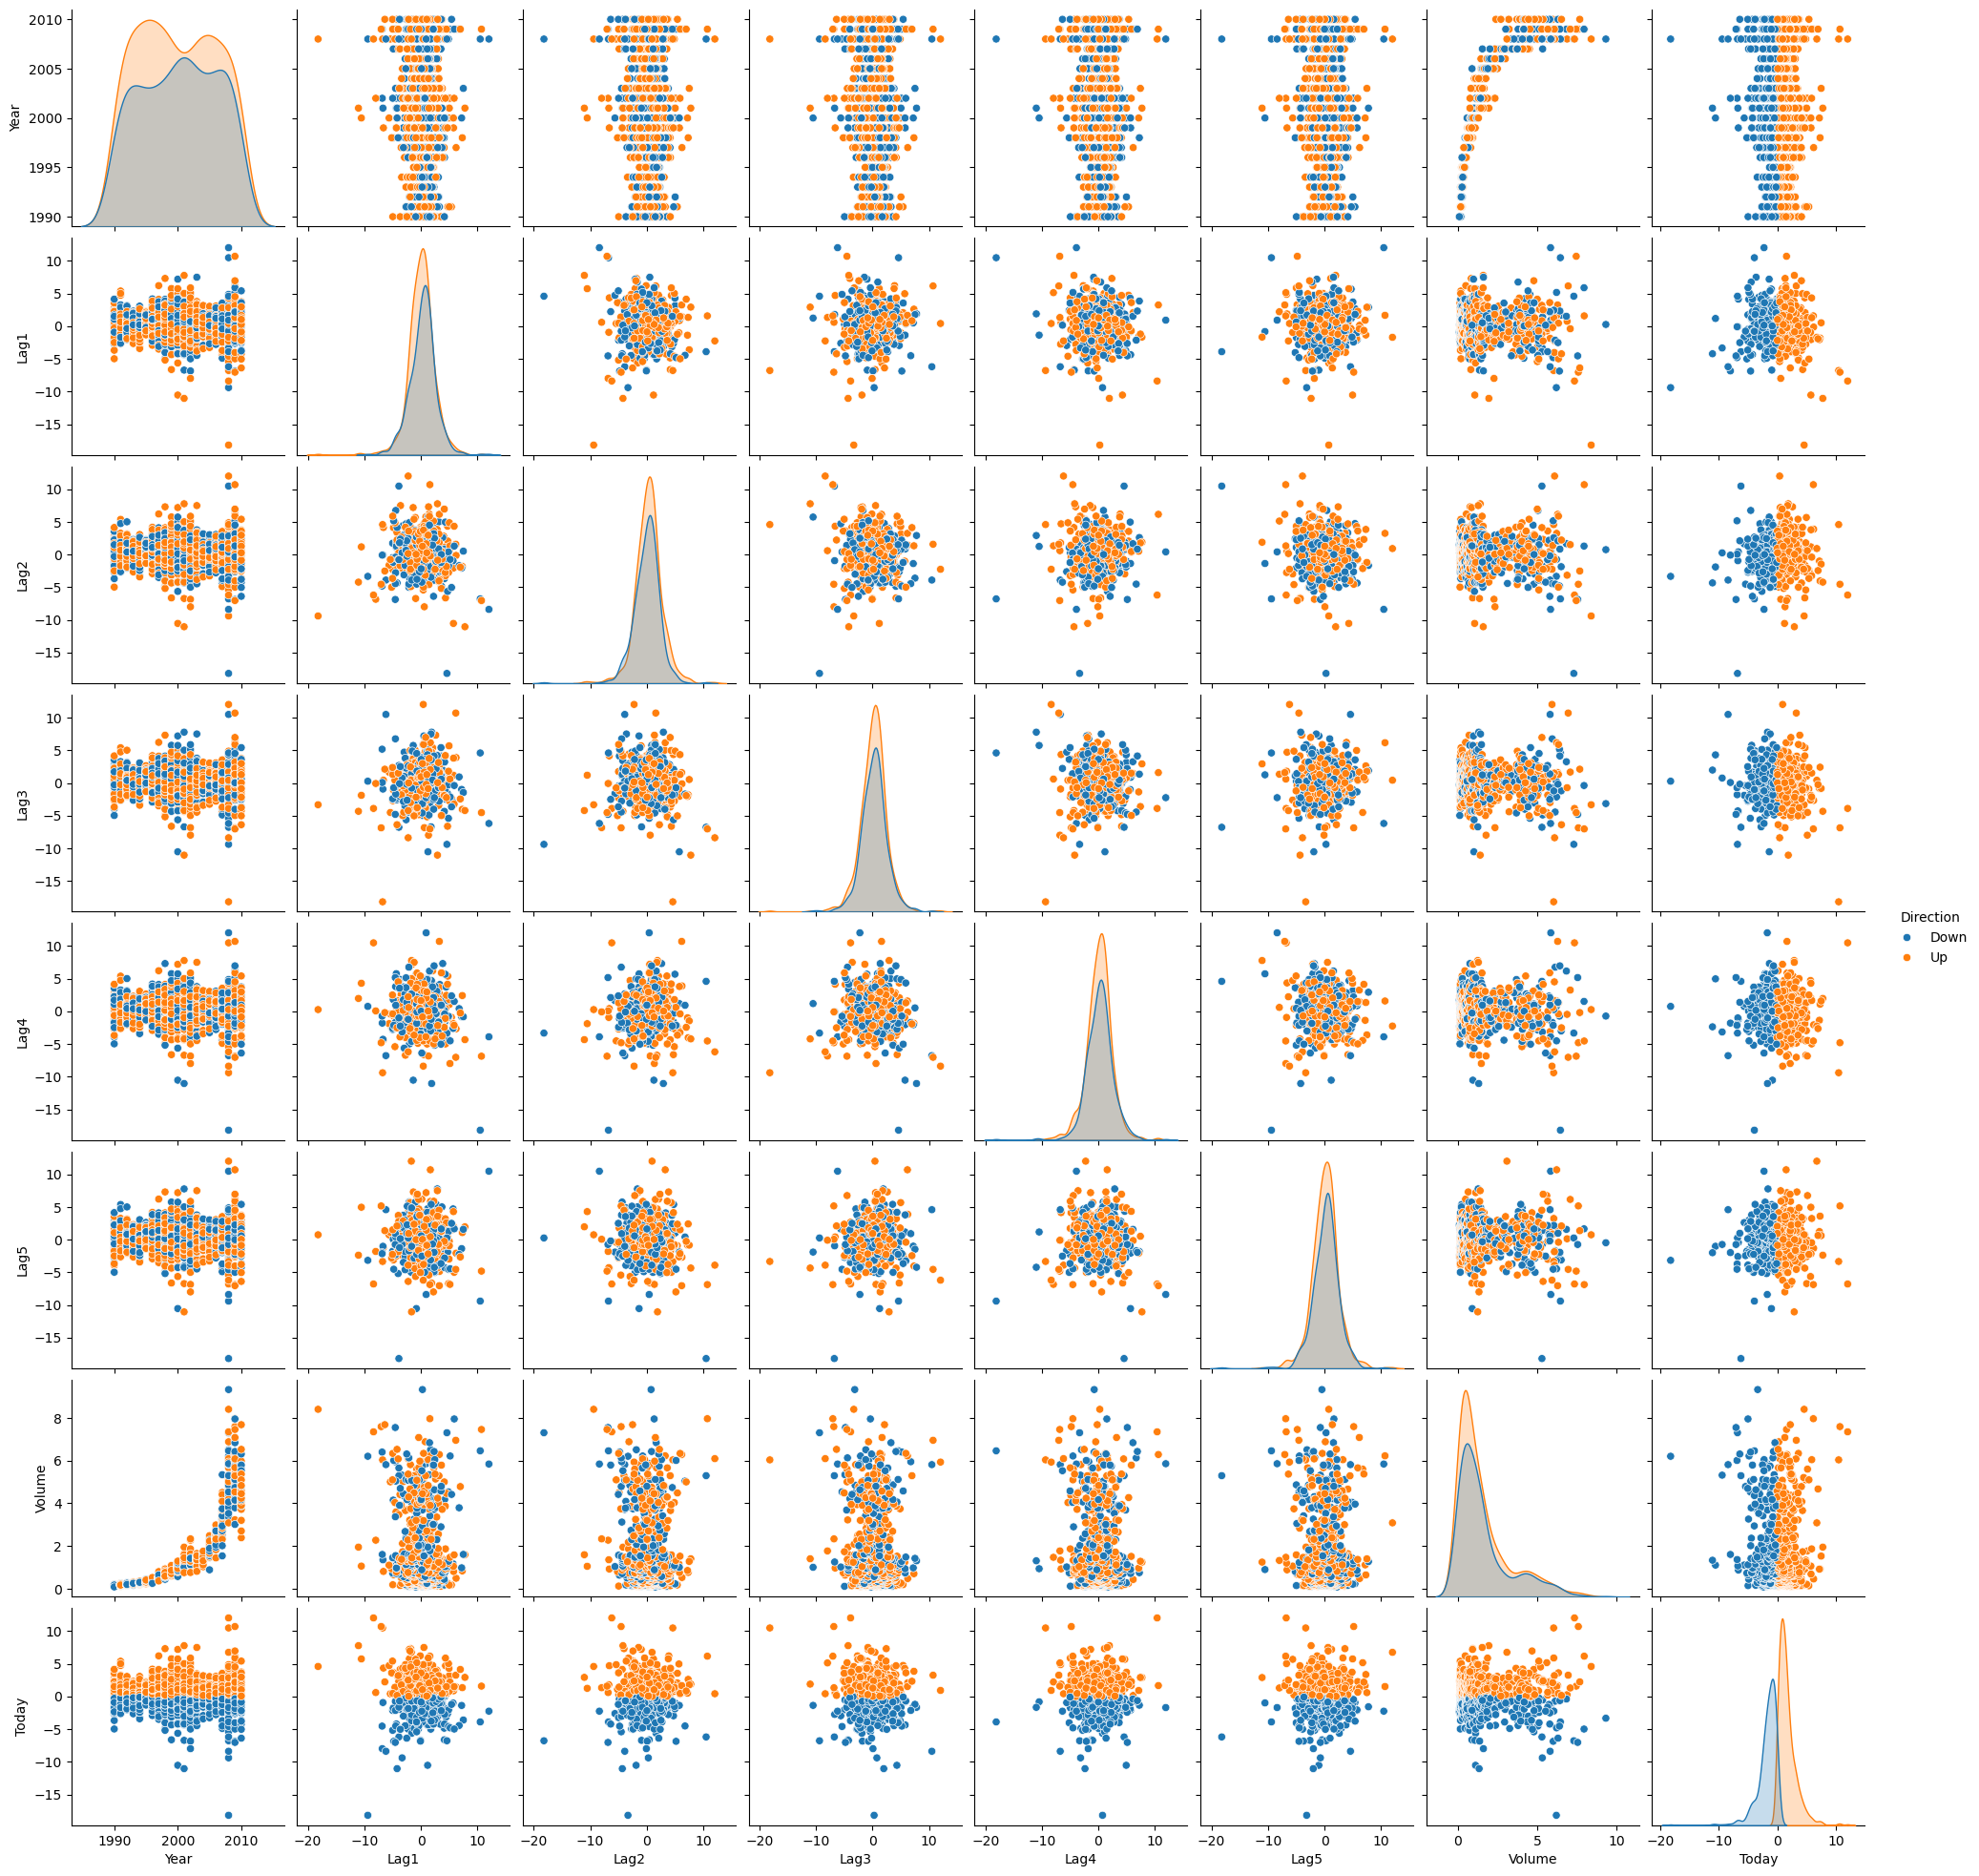

In [10]:
#Pairplot (optional)
sns.pairplot(weekly, hue='Direction')
plt.show()


In [11]:
# There are no strong patterns, but Lag2 shows a weak predictive signal.

##(b) Logistic regression (full data)Encode Direction
weekly['Direction_bin'] = weekly['Direction'].map({'Down': 0, 'Up': 1})


In [12]:
#Fit logistic regression
X = weekly[['Lag1','Lag2','Lag3','Lag4','Lag5','Volume']]
y = weekly['Direction_bin']

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X, y)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [14]:
#Coefficients
pd.Series(logreg.coef_[0], index=X.columns)


Lag1     -0.041234
Lag2      0.058392
Lag3     -0.016041
Lag4     -0.027779
Lag5     -0.014453
Volume   -0.022739
dtype: float64

In [15]:
#(c) Confusion matrix & accuracy (full data)
y_pred = logreg.predict(X)

confusion_matrix(y, y_pred)
accuracy_score(y, y_pred)


0.5610651974288338

In [16]:
#(d) Logistic regression (1990–2008 train, Lag2 only)Train / test split
train = weekly['Year'] <= 2008
test = weekly['Year'] > 2008

X_train = weekly.loc[train, ['Lag2']]
X_test = weekly.loc[test, ['Lag2']]
y_train = weekly.loc[train, 'Direction_bin']
y_test = weekly.loc[test, 'Direction_bin']


In [17]:
#Fit model
logreg2 = LogisticRegression()
logreg2.fit(X_train, y_train)

y_pred_test = logreg2.predict(X_test)

confusion_matrix(y_test, y_pred_test)
accuracy_score(y_test, y_pred_test)


0.625

In [18]:
#(e) LDA (Lag2 only)
lda = LDA()
lda.fit(X_train, y_train)

lda_pred = lda.predict(X_test)

confusion_matrix(y_test, lda_pred)
accuracy_score(y_test, lda_pred)


0.625

In [19]:
#(f) QDA (Lag2 only)
qda = QDA()
qda.fit(X_train, y_train)

qda_pred = qda.predict(X_test)

confusion_matrix(y_test, qda_pred)
accuracy_score(y_test, qda_pred)


0.5865384615384616

In [20]:
#(f) QDA (Lag2 only)
qda = QDA()
qda.fit(X_train, y_train)

qda_pred = qda.predict(X_test)

confusion_matrix(y_test, qda_pred)
accuracy_score(y_test, qda_pred)


0.5865384615384616

In [21]:
#(g) KNN (K = 1)
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

confusion_matrix(y_test, knn_pred)
accuracy_score(y_test, knn_pred)


0.5

In [22]:
#(h) Naive Bayes
nb = GaussianNB()
nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)

confusion_matrix(y_test, nb_pred)
accuracy_score(y_test, nb_pred)


0.5865384615384616

In [23]:
#(j) Experimenting with K in KNN
for k in [3,5,7,9,15]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred = knn.predict(X_test)
    print(f"K={k}, Accuracy={accuracy_score(y_test, pred):.3f}")


K=3, Accuracy=0.548
K=5, Accuracy=0.538
K=7, Accuracy=0.548
K=9, Accuracy=0.548
K=15, Accuracy=0.587


In [ ]:
#Final Conclusion (Exam-ready)

#Weekly stock movements are extremely difficult to predict

#Lag2 alone provides the strongest signal

#Simple models outperform complex ones

#Logistic regression, LDA, and Naive Bayes perform best